# Importing Libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("../data/processed/telco_churn_clean.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Dataset Overview

Dataset's Shape

In [3]:
df.shape

(7043, 21)

Dataset's Info

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

Checking for Nulls

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

## 2. Target Variable

In [8]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [9]:
df["Churn"].value_counts(normalize=True).mul(100).round(2)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

## 3. Feature Classification

In [10]:
id_column = ["customerID"]

target_column = ["Churn"]

numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [11]:
len(id_column) + len(target_column) + len(numerical_features) + len(categorical_features)

21

## 4. Numerical Data Quality Checks

In [12]:
df[numerical_features].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [14]:
(df[numerical_features] < 0).sum()

tenure            0
MonthlyCharges    0
TotalCharges      0
dtype: int64

In [15]:
for column in numerical_features:
    print(
        f"{column}: "
        f"min = {df[column].min()}, "
        f"max = {df[column].max()}"
    )

tenure: min = 0, max = 72
MonthlyCharges: min = 18.25, max = 118.75
TotalCharges: min = 0.0, max = 8684.8


## 5. Exploratory Data Analysis

In [16]:
df.groupby("Churn")["tenure"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.57,24.11,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.98,19.53,1.0,2.0,10.0,29.0,72.0


### 5.1 Tenure and Churn

In [17]:
tenure_bins = [-1, 12, 24, 48, 60, 72]

tenure_labels = [
    "0-12 months",
    "13-24 months",
    "25-48 months",
    "49-60 months",
    "61-72 months"
]

df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=tenure_bins,
    labels=tenure_labels
)

df["tenure_group"].value_counts().sort_index()

tenure_group
0-12 months     2186
13-24 months    1024
25-48 months    1594
49-60 months     832
61-72 months    1407
Name: count, dtype: int64

In [18]:
tenure_churn = pd.crosstab(
    df["tenure_group"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

tenure_churn

Churn,No,Yes
tenure_group,,
0-12 months,52.56,47.44
13-24 months,71.29,28.71
25-48 months,79.61,20.39
49-60 months,85.58,14.42
61-72 months,93.39,6.61


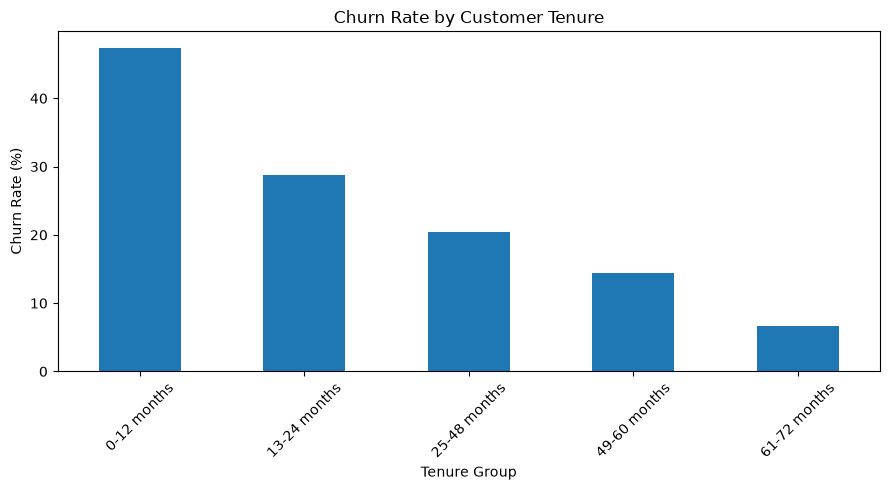

In [19]:
tenure_churn["Yes"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5.2 Monthly Charges and Churn

Monthly charges may be associated with customer churn. We compare the distribution of monthly charges between customers who churned and customers who remained.

In [20]:
df.groupby("Churn")["MonthlyCharges"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.27,31.09,18.25,25.10,64.43,88.4,118.75
Yes,1869.0,74.44,24.67,18.85,56.15,79.65,94.2,118.35


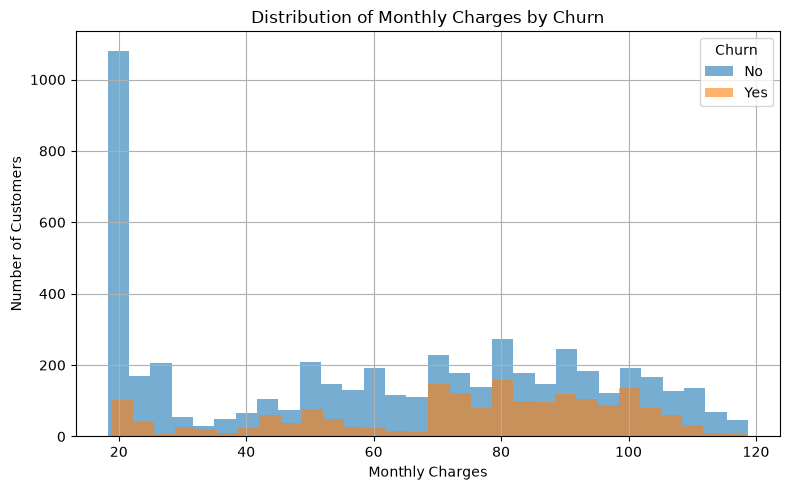

In [21]:
plt.figure(figsize=(8, 5))

df[df["Churn"] == "No"]["MonthlyCharges"].hist(
    bins=30,
    alpha=0.6,
    label="No"
)

df[df["Churn"] == "Yes"]["MonthlyCharges"].hist(
    bins=30,
    alpha=0.6,
    label="Yes"
)

plt.title("Distribution of Monthly Charges by Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

In [22]:
df.groupby("Churn")["MonthlyCharges"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.27,31.09,18.25,25.10,64.43,88.4,118.75
Yes,1869.0,74.44,24.67,18.85,56.15,79.65,94.2,118.35


**Observation:** Customers who churned generally had higher monthly charges than customers who remained. The median monthly charge was 79.65 among churned customers compared with 64.43 among retained customers. This suggests that monthly cost may be associated with churn; however, this relationship may also reflect differences in contract type, internet service, tenure, or other customer characteristics.

### 5.3 Contract Type and Churn

Contract structure may be associated with customer retention. Churn rates are compared across month-to-month, one-year, and two-year contracts.

In [24]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


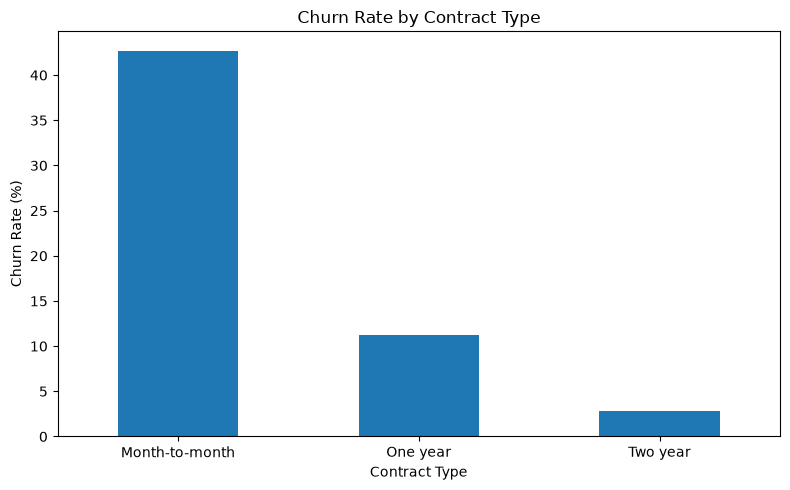

In [25]:
contract_churn["Yes"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:** Contract type shows a strong association with customer churn. Month-to-month customers have a churn rate of 42.71%, compared with 11.27% for one-year contracts and only 2.83% for two-year contracts. Customers with longer-term contracts therefore show substantially lower observed churn. This is an association and does not by itself establish that longer contracts cause lower churn.

### 5.4 Internet Service and Churn

Churn rates are compared across customers using DSL, fiber optic, or no internet service.

In [26]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


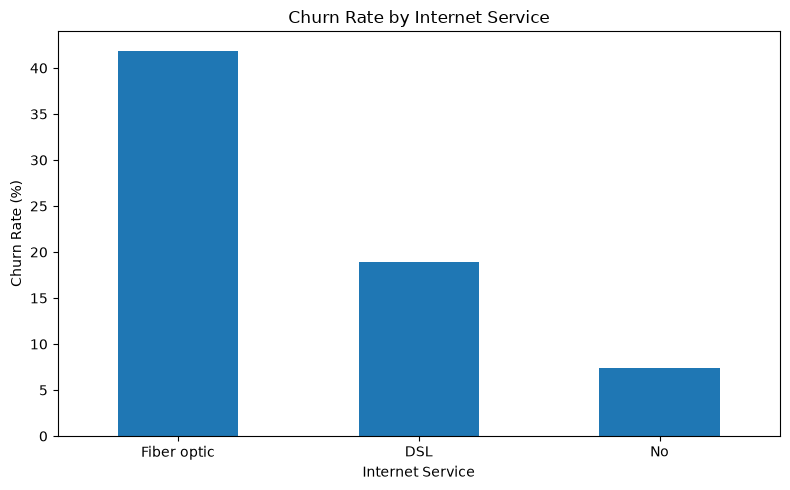

In [27]:
internet_churn["Yes"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:** Fiber-optic customers have the highest observed churn rate at 41.89%, compared with 18.96% for DSL customers and 7.40% for customers without internet service. This suggests that internet service type is associated with churn. However, the relationship may be influenced by other factors such as monthly charges, contract type, tenure, or bundled services.

### 5.5 Payment Method and Churn

Churn rates are compared across the different customer payment methods to identify whether billing behaviour is associated with customer retention.

In [28]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
).mul(100).round(2)

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


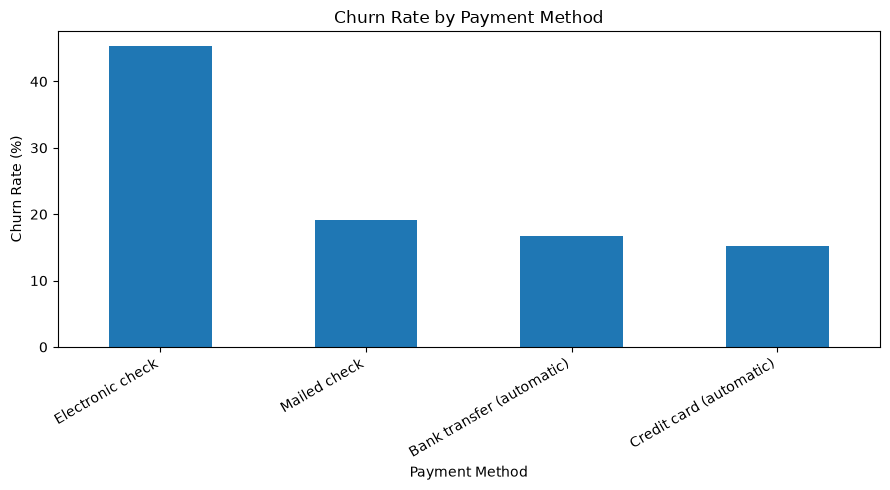

In [29]:
payment_churn["Yes"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Observation:** Customers using electronic checks have the highest observed churn rate at 45.29%. In comparison, churn rates are 19.11% for mailed checks, 16.71% for automatic bank transfers, and 15.24% for automatic credit card payments. Payment method therefore appears to be associated with churn, although this may overlap with other customer characteristics such as contract type, tenure, and monthly charges.

### 5.6 Interaction Between Contract Type and Internet Service

The previous analysis identified high churn among month-to-month customers and fiber-optic customers. We now examine these variables together to determine whether particular combinations are associated with especially high churn.

In [30]:
df["ChurnFlag"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [31]:
contract_internet_churn = (
    df.groupby(
        ["Contract", "InternetService"],
        observed=True
    )["ChurnFlag"]
    .agg(["count", "mean"])
    .reset_index()
)

contract_internet_churn["ChurnRate"] = (
    contract_internet_churn["mean"] * 100
).round(2)

contract_internet_churn[
    ["Contract", "InternetService", "count", "ChurnRate"]
]

,Contract,InternetService,count,ChurnRate
0,Month-to-month,DSL,1223,32.22
1,Month-to-month,Fiber optic,2128,54.61
2,Month-to-month,No,524,18.89
3,One year,DSL,570,9.30
4,One year,Fiber optic,539,19.29
5,One year,No,364,2.47
6,Two year,DSL,628,1.91
7,Two year,Fiber optic,429,7.23
8,Two year,No,638,0.78


In [32]:
contract_internet_pivot = (
    contract_internet_churn.pivot(
        index="Contract",
        columns="InternetService",
        values="ChurnRate"
    )
)

contract_internet_pivot.round(2)

InternetService,DSL,Fiber optic,No
Contract,,,
Month-to-month,32.22,54.61,18.89
One year,9.30,19.29,2.47
Two year,1.91,7.23,0.78


**Observation:** The interaction between contract type and internet service reveals a particularly high-risk customer profile. Month-to-month fiber-optic customers have the highest observed churn rate at 54.61%.

Contract duration is strongly associated with churn across all internet-service categories. For example, fiber-optic churn decreases from 54.61% among month-to-month customers to 19.29% for one-year contracts and 7.23% for two-year contracts.

Fiber-optic customers also show higher churn than DSL customers within each contract category, suggesting that the previously observed fiber-optic churn pattern is not explained by contract type alone.

These are observational relationships and should not be interpreted as causal effects.

In [33]:
df.groupby("InternetService")["MonthlyCharges"].agg(
    ["count", "mean", "median"]
).round(2)

,count,mean,median
InternetService,,,
DSL,2421,58.10,56.15
Fiber optic,3096,91.50,91.68
No,1526,21.08,20.15


In [34]:
(
    df.groupby(
        ["Contract", "InternetService"],
        observed=True
    )["MonthlyCharges"]
    .agg(["count", "mean", "median"])
    .round(2)
)

count    mean  median
Contract       InternetService                       
Month-to-month DSL               1223   50.22   50.20
               Fiber optic       2128   87.02   86.00
               No                 524   20.41   20.05
One year       DSL                570   61.40   61.05
               Fiber optic        539   98.78  100.15
               No                 364   20.82   20.10
Two year       DSL                628   70.46   73.30
               Fiber optic        429  104.57  106.30
               No                 638   21.78   20.35

**Observation:** Fiber-optic customers have substantially higher monthly charges than DSL customers across all contract types. For example, month-to-month fiber-optic customers pay an average of 87.02 per month compared with 50.22 for month-to-month DSL customers.

However, monthly charges alone do not explain the churn pattern. Within fiber-optic customers, average monthly charges increase from 87.02 for month-to-month contracts to 104.57 for two-year contracts, while the previously observed churn rate decreases from 54.61% to 7.23%.

This suggests that churn risk is associated with a combination of customer characteristics rather than monthly charges in isolation.

### 5.7 Interaction Between Contract Type and Payment Method

Electronic-check customers and month-to-month customers independently showed high churn rates. The following analysis examines whether these characteristics overlap.

In [35]:
contract_payment_churn = (
    df.groupby(
        ["Contract", "PaymentMethod"],
        observed=True
    )["ChurnFlag"]
    .agg(["count", "mean"])
    .reset_index()
)

contract_payment_churn["ChurnRate"] = (
    contract_payment_churn["mean"] * 100
).round(2)

contract_payment_churn[
    ["Contract", "PaymentMethod", "count", "ChurnRate"]
]

,Contract,PaymentMethod,count,ChurnRate
0,Month-to-month,Bank transfer (automatic),589,34.13
1,Month-to-month,Credit card (automatic),543,32.78
2,Month-to-month,Electronic check,1850,53.73
3,Month-to-month,Mailed check,893,31.58
4,One year,Bank transfer (automatic),391,9.72
5,One year,Credit card (automatic),398,10.30
6,One year,Electronic check,347,18.44
7,One year,Mailed check,337,6.82
8,Two year,Bank transfer (automatic),564,3.37
9,Two year,Credit card (automatic),581,2.24


In [36]:
contract_payment_pivot = contract_payment_churn.pivot(
    index="Contract",
    columns="PaymentMethod",
    values="ChurnRate"
)

contract_payment_pivot.round(2)

PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Contract,,,,
Month-to-month,34.13,32.78,53.73,31.58
One year,9.72,10.30,18.44,6.82
Two year,3.37,2.24,7.74,0.79


**Observation:** Electronic-check customers have the highest observed churn rate within each contract category. Among month-to-month customers, electronic-check users have a churn rate of 53.73%, compared with approximately 32–34% for the other payment methods.

Contract duration remains strongly associated with churn regardless of payment method. For electronic-check customers, churn decreases from 53.73% for month-to-month contracts to 18.44% for one-year contracts and 7.74% for two-year contracts.

This suggests that payment method and contract type both contain potentially useful information for predicting churn, while also showing substantial interaction between customer characteristics.

## 6. Key EDA Findings

The exploratory analysis identified several characteristics associated with customer churn:

- **Tenure:** Churn is substantially higher among newer customers and decreases as customer tenure increases.
- **Contract type:** Month-to-month customers have much higher observed churn than customers on one-year or two-year contracts.
- **Internet service:** Fiber-optic customers show considerably higher churn than DSL customers and customers without internet service.
- **Monthly charges:** Customers who churn tend to have higher monthly charges, although charges alone do not explain churn.
- **Payment method:** Electronic-check customers have the highest observed churn among the available payment methods.
- **Feature interactions:** The highest churn rates occur among combinations of characteristics. In particular, month-to-month fiber-optic customers show especially high churn, while electronic-check customers also remain higher-churn within each contract category.

These findings are observational associations rather than causal relationships. Several variables are related to one another, so multivariate modelling will be required to determine how much predictive information each feature contributes when considered alongside the others.